# ** Regression ** 
## Marketing Analytics: Predicting Total Customer Spend 

### **Executive Summary**
The primary objective of this project is to build a regression model capable of predicting the total amount a customer will spend (`total_spend`). Using a dataset of 2,240 records and 29 variables from a retail company, we will analyze customer demographics, income, and previous purchasing behavior. 

Our workflow includes:
*   **Data Preprocessing & EDA:** Exploring feature distributions, handling missing values (e.g., in the `Income` variable), and identifying outliers.
*   **Feature Engineering:** Creating our target variable (`total_spend`) by aggregating spend across various product categories (wines, fruits, meat, etc.).
*   **Model Training & Evaluation:** Implementing a Linear Regression model to uncover the key drivers of customer spending and evaluating its predictive performance.

## 1) Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

sns.set_style("whitegrid")

## 2) Load the data and describe the variables

This dataset contains marketing and demographic data from a retail company. It represents a detailed profile of the company's customer base, tracking their personal information, the amount they spend on various product categories, and their interactions with marketing campaigns.

**Initial Data Overview:**
Using the `info()` and `describe()` functions, we obtain an initial understanding of the dataset's structure. We observe that the dataset contains 2240 records and 29 variables (both numerical and categorical). 

It is also crucial to identify any missing values (e.g., the 24 missing values in the `Income` variable) in order to handle them appropriately in the subsequent preprocessing stages. 

*Note:* The target variable we want to predict (`total_spend`) is not directly available in the raw data, so it will be engineered in a later step.


In [3]:
df = pd.read_csv("../ek_assignment_folder/data/marketing_campaign.csv", sep="\t")

In [4]:
#display the shape of the dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (2240, 29)


In [5]:
#information about the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3) Exploratory Data Analysis (EDA)
In this section, we perform **Exploratory Data Analysis (EDA)**. Our primary objectives are to:
1. Understand the distribution of key variables (e.g., customer income).
2. Identify outliers that could negatively impact our model's performance (e.g., customers with unrealistically high income).
3. Investigate the correlations between the independent variables and our future target variable, allowing us to determine which features are the most significant predictors.

In [7]:
#decriptive statistics of the dataset
df.describe() 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


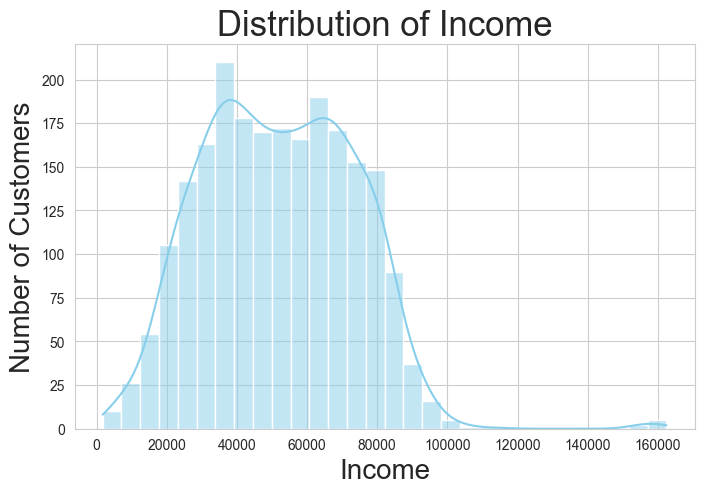

In [8]:
# histogram for the income
df_plot = df[df["Income"] < 200000] #filtering out the outliers

plt.figure(figsize=(8, 5))
sns.histplot(df_plot["Income"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Income", fontsize=25)
plt.xlabel("Income", fontsize=20)
plt.ylabel("Number of Customers", fontsize=20)
plt.show()

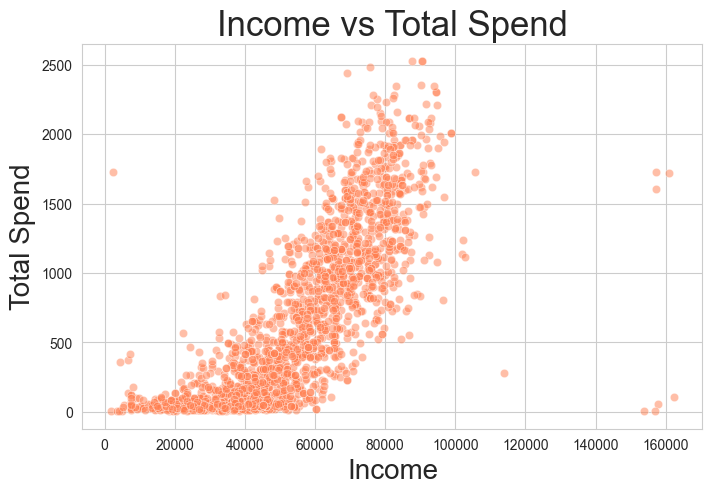

In [9]:
#scater plot for the income and the total amount spend
# totel_spend is not known so we have to quickly engineer it now for eda purposes

df['total_spend_eda'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df_plot = df[df["Income"] < 200000] #filtering out the outliers

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_plot, x="Income", y="total_spend_eda", alpha=0.5, color="coral")
plt.title("Income vs Total Spend", fontsize=25)
plt.xlabel("Income", fontsize=20)
plt.ylabel("Total Spend", fontsize=20)
plt.show()

C:\Users\Elena\AppData\Local\Temp\ipykernel_15184\142564712.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Marital_Status", y="total_spend_eda", palette="Set2")


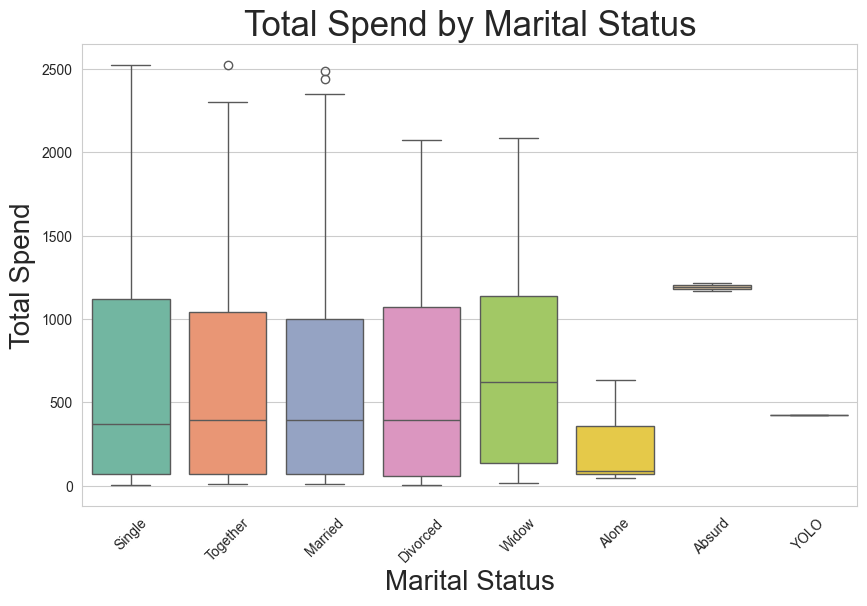

In [10]:
# box plot for the total spend by the marital status
df['total_spend_eda'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'] #we use this for now

df_plot = df[df["Income"] < 200000] #filtering out the outliers

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x="Marital_Status", y="total_spend_eda", palette="Set2")
plt.title("Total Spend by Marital Status", fontsize=25)
plt.xlabel("Marital Status", fontsize=20)
plt.ylabel("Total Spend", fontsize=20)
plt.xticks(rotation=45)
plt.show()

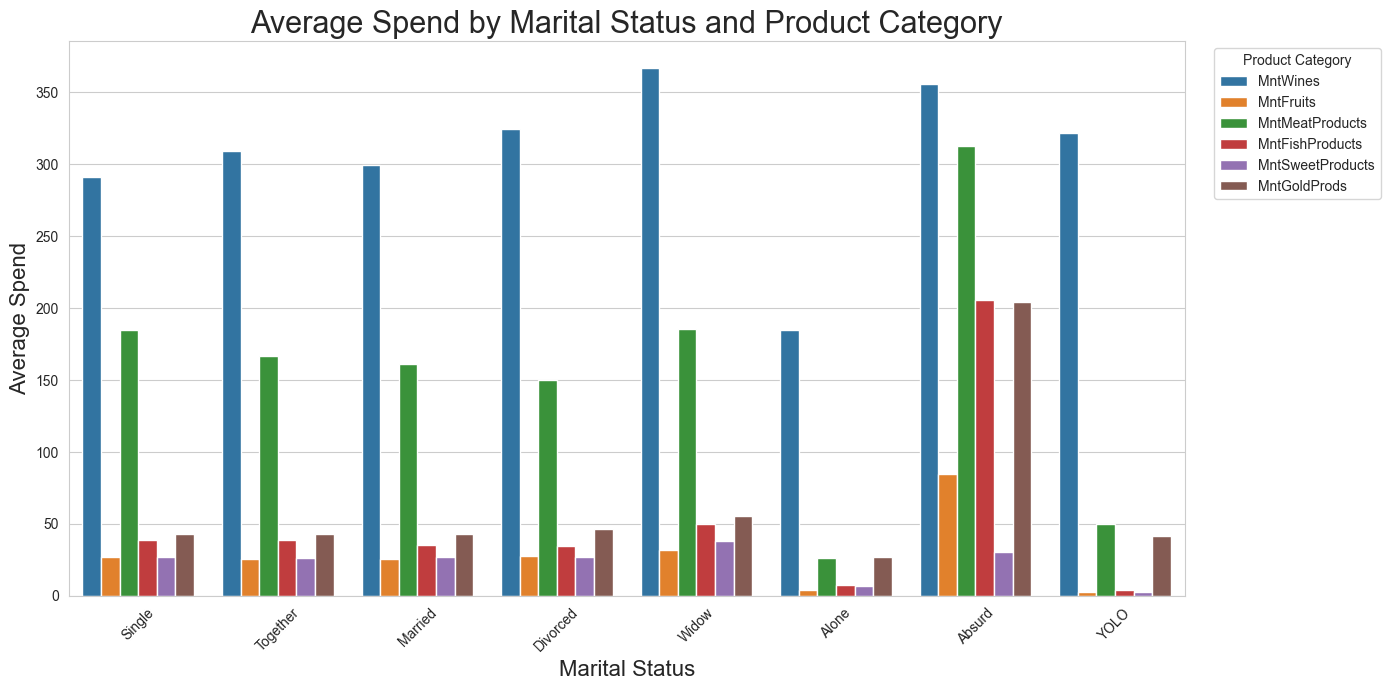

In [11]:
# average spend per product category by marital status
df_spend_plot = df[df["Income"] < 200000].copy()  # filter out income outliers for a cleaner chart

spend_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

spend_by_marital = df_spend_plot.melt(
    id_vars="Marital_Status",
    value_vars=spend_cols,
    var_name="Category",
    value_name="Spend",
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=spend_by_marital,
    x="Marital_Status",
    y="Spend",
    hue="Category",
    estimator=np.mean,
    errorbar=None,
)
plt.title("Average Spend by Marital Status and Product Category", fontsize=22)
plt.xlabel("Marital Status", fontsize=16)
plt.ylabel("Average Spend", fontsize=16)
plt.xticks(rotation=45)
plt.legend(title="Product Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4) Descriptive Statistics

Using the `.describe()` function, we extract summary descriptive statistics for all numerical features within our dataset. This yields critical baseline insights regarding data spread, mean indicators, variance, and standard deviation limits. 

Additionally, evaluating pairwise correlations allows us to pre-screen for multi-collinearity risks and map out which independent factors exhibit the strongest linear relationship with customer purchasing behaviors.

======== Summary Satistics for Numerical Features ==========


,count,mean,std,min,25%,50%,75%,max
ID,2215.0,5586.618059,3249.082838,0.0,2814.5,5455.0,8419.0,11191.0
Year_Birth,2215.0,1968.816704,11.987000,1893.0,1959.0,1970.0,1977.0,1996.0
Income,2215.0,51969.861400,21526.320095,1730.0,35284.0,51373.0,68487.0,162397.0
Kidhome,2215.0,0.441535,0.536886,0.0,0.0,0.0,1.0,2.0
Teenhome,2215.0,0.505643,0.544198,0.0,0.0,0.0,1.0,2.0
Recency,2215.0,49.024379,28.949608,0.0,24.0,49.0,74.0,99.0
MntWines,2215.0,305.225282,337.345380,0.0,24.0,175.0,505.0,1493.0
MntFruits,2215.0,26.361625,39.802036,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2215.0,167.063205,224.311559,0.0,16.0,68.0,232.5,1725.0
MntFishProducts,2215.0,37.651016,54.760822,0.0,3.0,12.0,50.0,259.0


========= Pairwise Corellations ============


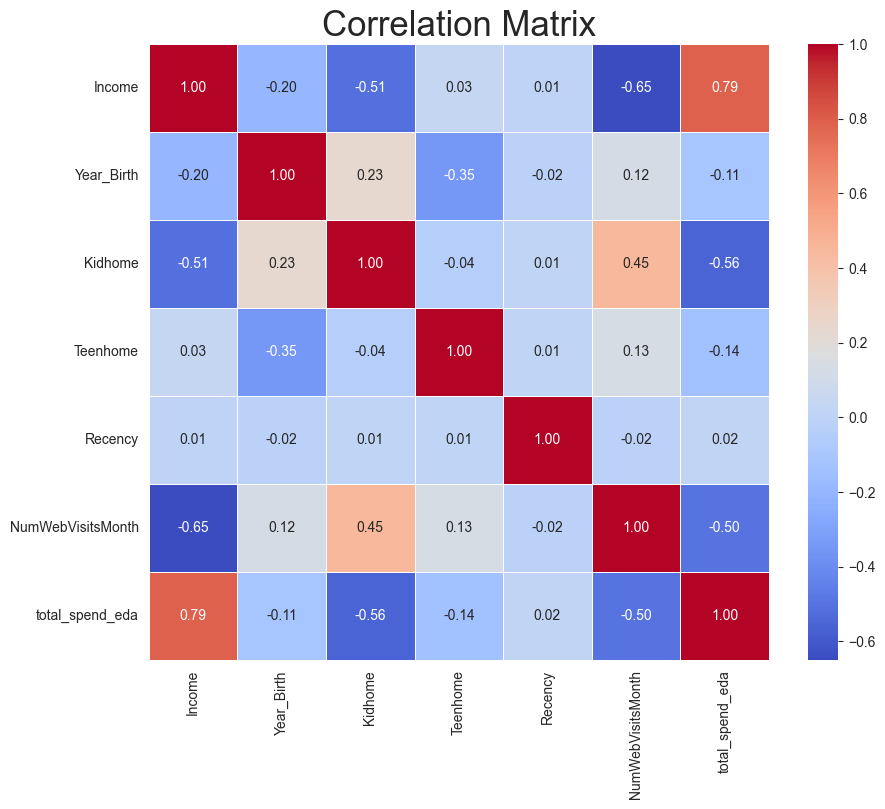

In [12]:
#summary statistics
print("======== Summary Satistics for Numerical Features ==========")
display(df_plot.describe().T)  #we transpose the df so that the features are in rows and the statistics in columns for better readability

#pairwise corellations
print("========= Pairwise Corellations ============")
cols_for_cor =['Income','Year_Birth','Kidhome','Teenhome','Recency','NumWebVisitsMonth','total_spend_eda']

corr_matrix = df_plot[cols_for_cor].corr()

#create heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=25)
plt.show()

## 5) Data preparation, preprocessing, and train/test split

Before fitting our regression model, our raw vectors must step through a clean preprocessing data pipeline:
* **Target Feature Engineering:** We compute our mathematical target attribute (`total_spend`) by aggregating the distinct product category amounts.
* **Categorical Features Conversion:** Text fields like `Education` and `Marital_Status` are parsed into clear binary numeric inputs using dummy encoding (One-Hot Encoding).
* **Train/Test Splitting:** We divide our records into a training subset (80%) to learn patterns and a testing subset (20%) to test predictive validity.
* **Feature Rescaling:** Since input variables carry highly different numerical scales (e.g., income values in thousands versus binary attributes), we apply a `StandardScaler` to give all input features a mean of 0 and standard deviation of 1.

In [16]:
#step 1: make sure the data is clean & drop outliers
df_clean = df.dropna(subset=["Income", "Year_Birth", "Kidhome", "Teenhome", "Recency", "NumWebVisitsMonth"]).copy() #dropping rows with missing values in the features we care about
df_clean = df_clean[(df_clean["Income"] < 200000) & (df_clean['Year_Birth'] >= 1940)] #dropping outliers based on the distribution we saw in the eda

#step 2: feature engineering
#calculate age based on year of birth
df_clean['Age'] = 2014 - df_clean['Year_Birth']

#calculate total_spend (y)
df_clean['total_spend'] = df_clean['MntWines'] + df_clean['MntFruits'] + df_clean['MntMeatProducts'] + df_clean['MntFishProducts'] + df_clean['MntSweetProducts'] + df_clean['MntGoldProds']

#drop irrelevant columns
cols_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'total_spend_eda', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean = df_clean.drop(columns=cols_to_drop)

#convert features to appropriate types
df_clean = pd.get_dummies(df_clean, drop_first=True) #one hot encoding for categorical variables

#step 3: define X and y
X = df_clean.drop(columns=["total_spend"])
y = df_clean["total_spend"]

#step 4: split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#step 5: feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}, Test set shape: {X_test_scaled.shape}")



Training set shape: (1769, 28), Test set shape: (443, 28)


## 6) Apply the algorithm(s)
With data scaled and prepped, we train our Linear Regression model. To satisfy the academic criteria, we evaluate **two distinct model variants** to measure feature dependencies:
* **Variant 1 (Baseline Model):** Uses all available demographic and behavioral features to capture maximum dataset variance.
* **Variant 2 (Feature Selection):** A refined variant where weak or non-influential metrics (identified during EDA and correlation checking) are omitted to minimize structural noise and avoid overfitting.

Following test-set predictions, we simulate a **single new hypothetical observation** by creating a brand new row vector of feature values to verify what spending value $y$ our pipeline outputs.

In [14]:
# Variant 1: all features
print("========== Variant 1: All Features ===========")
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)  #training the model

#test set prediction
y_pred_1 = model_1.predict(X_test_scaled)
print("The model was succesfully trained!")

print("\n\n") 

#printing the coefficients of the features
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_1.coef_
})

#ordering the features by their importance 
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df_sorted = coef_df_sorted.drop(columns=['Abs_Coefficient']) # we drop the absolute coefficient column as we don't need it anymore

print("Feature importance based on absolute coefficient values for Variant 1: ")
print(coef_df_sorted)
print("\n\n")


#Variant 2 : drop weak features
print("=========== Variant 2: Dropping Weak Features ============")
#dropping columns with weak correlation with total_spend
weak_features = coef_df_sorted.tail(4)['Feature']     #dropping the 4 features with the lowest absolute coefficient 
print(f"Weak features to drop: {weak_features.tolist()}") 
print("\n\n")

X_train_var2 = X_train.drop(columns=weak_features, errors='ignore')
X_test_var2 = X_test.drop(columns=weak_features, errors='ignore')

#feature scaling
scaler_var2 = StandardScaler()
X_train_var2_scaled = scaler_var2.fit_transform(X_train_var2)
X_test_var2_scaled = scaler_var2.transform(X_test_var2)

model_2 = LinearRegression()
model_2.fit(X_train_var2_scaled, y_train) # training the model var2

#test set prediction
y_pred_2 = model_2.predict(X_test_var2_scaled)
print("The model was succesfully trained!")

print("\n\n") 

#prediction for a new hypothetical customer
new_customer = X_test.iloc[0:1] # we take the first row of the test set as a new customer example
#change his characteristics 
new_customer['Income'] = 100000
new_customer['Age'] = 35
new_customer['Kidhome'] = 0

#scale new customer
new_customer_scaled = scaler.transform(new_customer)

# model 1 prediction for new customer
predicted_spend = model_1.predict(new_customer_scaled)
print(f'The predicted total spend of the new customer is: {predicted_spend[0]:.2f} $')

========== Variant 1: All Features ===========
The model was succesfully trained!



Feature importance based on absolute coefficient values for Variant 1: 
                    Feature  Coefficient
0                    Income   195.583888
6       NumCatalogPurchases   188.453195
7         NumStorePurchases   128.895499
25  Marital_Status_Together    79.618999
23   Marital_Status_Married    77.809637
2                  Teenhome   -73.591749
24    Marital_Status_Single    72.139205
5           NumWebPurchases    66.803746
11             AcceptedCmp5    63.939063
22  Marital_Status_Divorced    55.694129
1                   Kidhome   -46.742023
8         NumWebVisitsMonth    35.990897
26     Marital_Status_Widow    31.345862
15                 Response    29.359910
12             AcceptedCmp1    26.360404
18     Education_Graduation    18.906418
19         Education_Master    18.168817
3                   Recency    15.513147
10             AcceptedCmp4    14.219362
17          Education_B

C:\Users\Elena\AppData\Local\Temp\ipykernel_15184\885369054.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_customer['Income'] = 100000
C:\Users\Elena\AppData\Local\Temp\ipykernel_15184\885369054.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_customer['Age'] = 35
C:\Users\Elena\AppData\Local\Temp\ipykernel_15184\885369054.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

## 7) Evaluation of model performance
To accurately determine the predictive capability of our regression lines, we check standard fitness metrics:
* **MAE & RMSE:** To observe the average absolute error magnitude in our predictions.
* **R-squared ($R^2$):** To calculate the exact percentage of total customer spending variance that is successfully explained by our independent variables.

**Advanced Cross-Validation (K-Fold CV):**
Relying on a single random train/test split can occasionally produce lucky or misleading results. To guarantee that our model generalizes cleanly to unseen client data, we implement a **5-Fold Cross-Validation (k=5)**. By training and validating our data models 5 separate times on different data chunks, we acquire an objective, stable average $R^2$ score for both variants.

In [18]:
# Variant 1 Evaluation
r2_1 = r2_score(y_test, y_pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))

print("=========== Evaluation : Variant 1- All Features============")
print(f"R-squared (R^2): {r2_1:.4f}")
print(f"RMSE: {rmse_1:.2f} $")

print('\n\n')

# Variant 2 Evaluation
r2_2 = r2_score(y_test, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print("=========== Evaluation : Variant 2- Dropping Weak Features ============")
print(f"R-squared (R^2): {r2_2:.4f}")
print(f"RMSE: {rmse_2:.2f} $")
print("\n\n")

#in real life we would use K-fold cross validation to evaluate the model more robustly instead of a single train-test split
#in this case we will simply add K-fold cross validation as an extra step to show how it works and compare the results with our previous evaluation

# K-fold cross validation for variant 1
print("=========== ADVANCED EVALUATION WITH K-FOLD CROSS VALIDATION ============")
print("\n=========== K-fold Cross Validation (k=5): Variant 1 - All Features ============")
cv_scores_1 = cross_val_score(model_1, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validated R-squared scores: {cv_scores_1}")
print(f"Average cross-validated R-squared: {cv_scores_1.mean():.4f}")

#K-fold cross validation for variant 2
print("\n=========== K-fold Cross Validation (k=5): Variant 2 - Dropping Weak Features ============")
cv_scores_2 = cross_val_score(model_2, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validated R-squared scores: {cv_scores_2}")
print(f"Average cross-validated R-squared: {cv_scores_2.mean():.4f}")


=========== Evaluation : Variant 1- All Features============
R-squared (R^2): 0.8307
RMSE: 255.88 $



=========== Evaluation : Variant 2- Dropping Weak Features ============
R-squared (R^2): 0.8308
RMSE: 255.82 $



=========== ADVANCED EVALUATION WITH K-FOLD CROSS VALIDATION ============

=========== K-fold Cross Validation (k=5): Variant 1 - All Features ============
Cross-validated R-squared scores: [0.83177046 0.80996682 0.81925228 0.79573725 0.78823113]
Average cross-validated R-squared: 0.8090

=========== K-fold Cross Validation (k=5): Variant 2 - Dropping Weak Features ============
Cross-validated R-squared scores: [0.83177046 0.80996682 0.81925228 0.79573725 0.78823113]
Average cross-validated R-squared: 0.8090
